In [2]:
import math
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
import plotly.graph_objects as go
plt.style.use ('fivethirtyeight')
import plotly.express as px

In [3]:
#Reading data set and setting the index as Date
df = pd.read_csv('BTC-USD.csv')
df = df.set_index('Date')

In [4]:
#Droping null values
df=df.dropna()

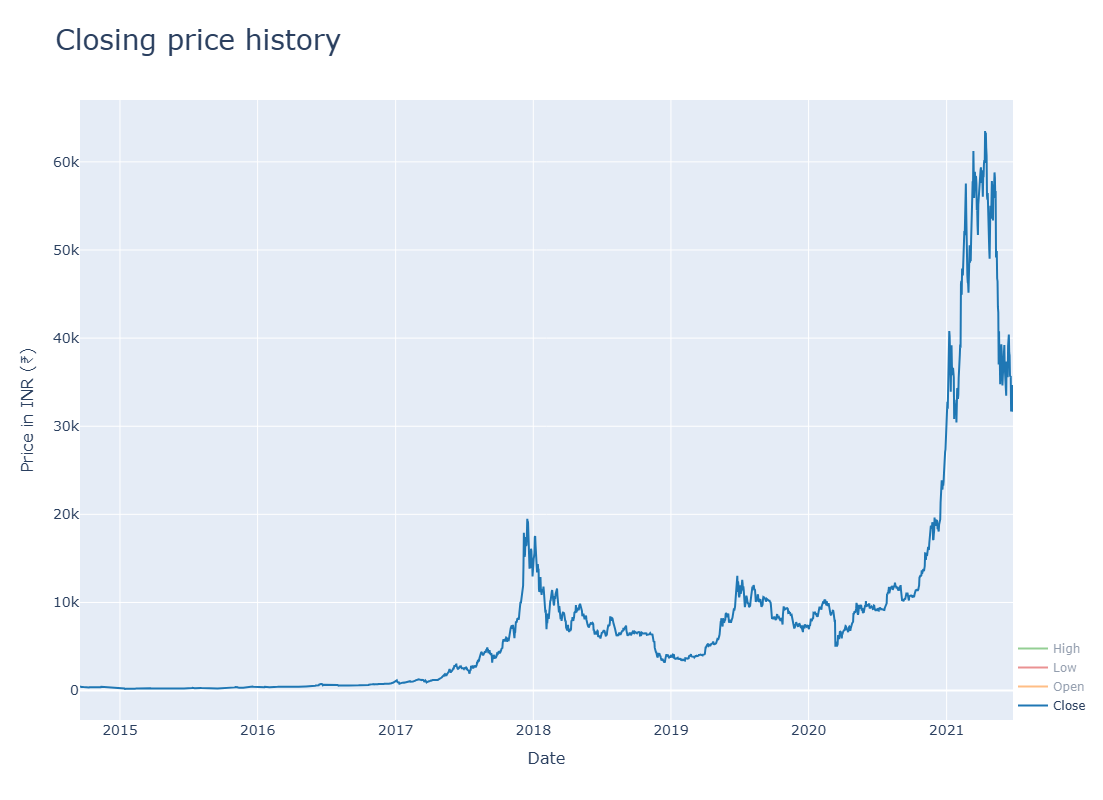

In [6]:
#Showing the graph High, Low, Open, Close in Our dataset. x=Date y=INR
fig = go.Figure()
fig.add_trace(go.Scatter(x = df.index, y = df.High,mode='lines',name='High',marker_color = '#2CA02C',visible = "legendonly"))
fig.add_trace(go.Scatter(x = df.index, y = df.Low,mode='lines',name='Low',marker_color = '#D62728',visible = "legendonly"))
fig.add_trace(go.Scatter(x = df.index, y = df.Open,mode='lines',name='Open',marker_color = '#FF7F0E',visible = "legendonly"))
fig.add_trace(go.Scatter(x = df.index, y = df.Close,mode='lines',name='Close',marker_color = '#1F77B4'))

fig.update_layout(
    title={
        'text': 'Closing price history',
        'font': {'size': 28}
    },
    xaxis=dict(
        title={'text': 'Date', 'font': {'size': 16}},
        tickfont={'size': 14}
    ),
    yaxis=dict(
        title={'text': 'Price in INR (₹)', 'font': {'size': 16}},
        tickfont={'size': 14}
    ),
    height=800,
    legend=dict(
        y=0,
        x=1.0,
        bgcolor='rgba(255, 255, 255, 0)',
        bordercolor='rgba(255, 255, 255, 0)'
    )
)

fig.show()

### Preprocessing

In [7]:
data = df.filter(['Close'])
dataset = data.values
training_data_len = math.ceil(len(dataset) * .8)

### MinMaxScaler Formula
X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

X_scaled = X_std * (max - min) + min

In [9]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)
scaled_data

array([[0.00440947],
       [0.00389002],
       [0.0034219 ],
       ...,
       [0.5445581 ],
       [0.49679432],
       [0.50468148]], shape=(2471, 1))

In [10]:
train_data = scaled_data[0:training_data_len, :]
x_train = []
y_train = []
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

In [11]:
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_train.shape

(1917, 60, 1)

### LSTM

In [12]:
model = Sequential()
model.add(LSTM(50, return_sequences = True, input_shape = (x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences = False))
model.add(Dense(25))
model.add(Dense(1))
model.compile(optimizer = 'adam', loss = 'mean_squared_error') #dog=input output=cat
model.fit(x_train, y_train, batch_size = 1, epochs = 5)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 2.0152e-04
Epoch 2/5
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - loss: 1.0117e-04
Epoch 3/5
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - loss: 6.6479e-05
Epoch 4/5
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - loss: 6.4060e-05
Epoch 5/5
1917/1917 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - loss: 6.2486e-05


In [13]:
test_data = scaled_data[training_data_len - 60: , :]
x_test = []
y_test = dataset[training_data_len:, :]

for i in range (60, len(test_data)):
    x_test.append(test_data[i - 60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

rsme = np.sqrt(np.mean(predictions - y_test) ** 2)
rsme

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step 


np.float64(795.2487091754805)

In [14]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

C:\Users\Admin\AppData\Local\Temp\ipykernel_16340\2657761684.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



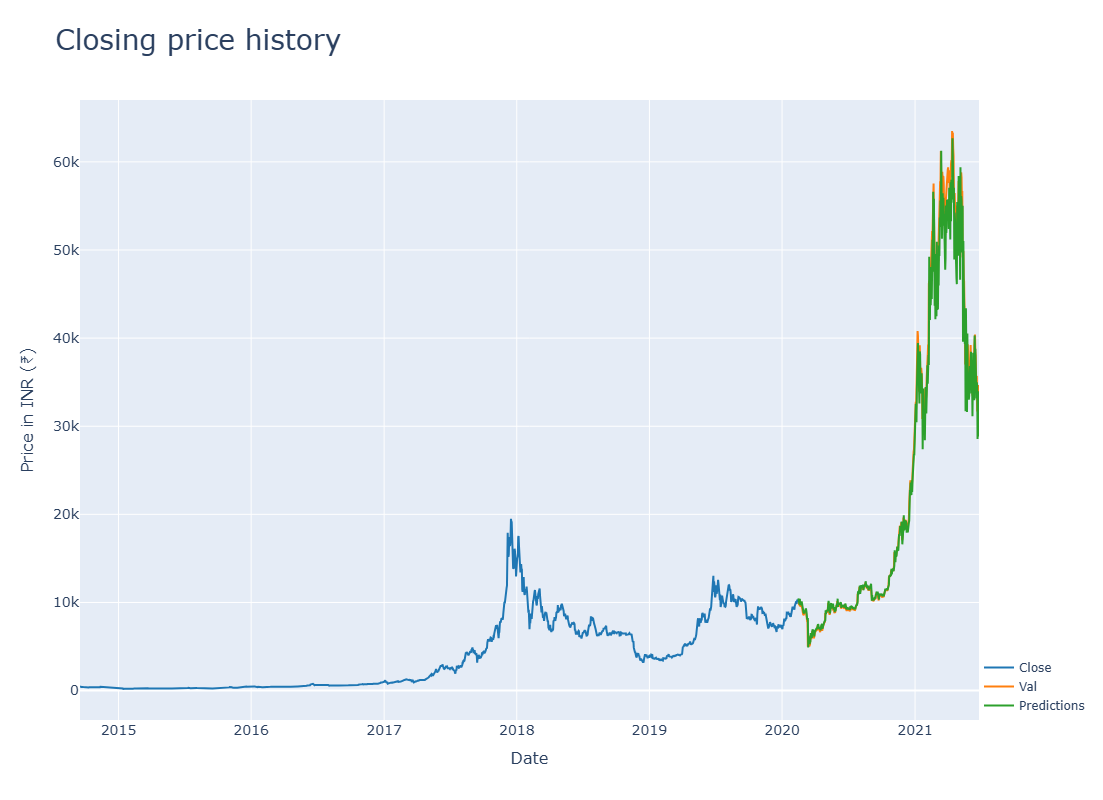

In [16]:
fig = go.Figure()
fig.add_trace(go.Scatter(x = train.index, y = train.Close,mode='lines',name='Close',marker_color = '#1F77B4'))
fig.add_trace(go.Scatter(x = valid.index, y = valid.Close,mode='lines',name='Val',marker_color = '#FF7F0E'))
fig.add_trace(go.Scatter(x = valid.index, y = valid.Predictions,mode='lines',name='Predictions',marker_color = '#2CA02C'))

fig.update_layout(
    title={
        'text': 'Closing price history',
        'font': {'size': 28}
    },
    xaxis=dict(
        title={'text': 'Date', 'font': {'size': 16}},
        tickfont={'size': 14}
    ),
    yaxis=dict(
        title={'text': 'Price in INR (₹)', 'font': {'size': 16}},
        tickfont={'size': 14}
    ),
    height=800,
    legend=dict(
        y=0,
        x=1.0,
        bgcolor='rgba(255, 255, 255, 0)',
        bordercolor='rgba(255, 255, 255, 0)'
    )
)
fig.show()